In [2]:
import json
import re
import numpy as np
import pandas as pd
import seaborn as sns
import glob
from IPython.display import Markdown, display
import pygwalker as pyg
from pygwalker.api.streamlit import StreamlitRenderer
import streamlit as st
import webbrowser
import matplotlib.pyplot as plt
import ipywidgets as widgets
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown, ToggleButtons, SelectMultiple, interactive, fixed, interact_manual, VBox, HBox, Label
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

2025-05-09 17:16:55.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
from data_processor import load_test_data, load_defect_data
tdf = load_test_data()
ddf_dp = load_defect_data(file_pattern="defect/2025_defect*.json")
print(f"测试数据: {tdf.shape}, 缺陷数据: {ddf_dp.shape}")

In [6]:
dfs = []
for file in glob.glob("defect/2025_defect.json"):
    with open(file, encoding="utf8") as f:
        data = json.load(f)
        dfs.append(pd.json_normalize(data, max_level=0))
ddf = pd.concat(dfs, ignore_index=True)

In [7]:
ddf['creation_time'] = ddf['creation_time'].str.replace('T', ' ').str.replace('Z', '')
ddf['creation_time'] = pd.to_datetime(ddf['creation_time'], format='%Y-%m-%d %H:%M:%S')
ddf['test_week'] = 'CW' + ddf['creation_time'].dt.isocalendar().week.astype("string").str.zfill(2)

In [8]:
ddf["occurrence"] = ddf["error_occurrence_udf"].apply(lambda x: x["name"] if x!=None else "")
ddf["severity"] = ddf["problem_severity_udf"].apply(lambda x: x["name"] if x!=None else "")
ddf["status_phase"] = ddf["phase"].apply(lambda x: x["name"] if x!=None else "")
ddf["solution"] = ddf["solution_responsible_udf"].apply(lambda x: x["name"] if x!=None else "")
ddf["parent_child"] = ddf["parent_child_udf"].apply(lambda x: x["name"] if x!=None else "")
ddf["blocking_reason"] = ddf["blocking_reason_udf"].apply(lambda x: x["name"] if x!=None else "")
ddf["pu"] = ddf["first_use_sop_of_function_udf"].apply(lambda x: x["name"] if x!=None else "")
ddf["tester"] = ddf["detected_by"].apply(lambda x: x["full_name"] if x!=None else "")
ddf["project"] = ddf["assigned_ecu_udf"].apply(lambda x: x["name"] if x!=None else "")
ddf["release"] = ddf["detected_in_release"].apply(lambda x: x["name"] if x!=None else "")
ddf["istep"] = ddf["involved_i_step1_udf"].apply(lambda x: x["name"] if x!=None else "")
ddf["lead_model"] = ddf["lead_model_udf"].apply(lambda x: x["name"] if x!=None else "")
ddf["tags"] = ddf["user_tags"].apply(lambda x: [i["name"] for i in x["data"]] if x!=None else "")
ddf["ticket_quality"] = ddf["tqr_udf"].apply(lambda x: [i["name"] for i in x["data"]] if x!=None else "")
ddf["aidas"] = ddf["product_areas"].apply(lambda x: [i["name"] for i in x["data"]] if x!=None else "")

In [9]:
ddf["ECU Pingpong"] = ddf["ecu_no_of_changes_udf"]

In [10]:
def extract_matrix(tags):
    if isinstance(tags, list):
        matrix_tags = [tag for tag in tags if tag.lower().startswith('matrix-')]
        return matrix_tags[0] if matrix_tags else ""
    return ""
ddf["matrix"] = ddf["tags"].apply(extract_matrix)

In [11]:
def categorize_complexity(pingpong_value):
    if pingpong_value == 0:
        return 'simple'
    elif pingpong_value in [1, 2]:
        return 'medium'
    elif pingpong_value > 2:
        return 'complex'
    else:  # 处理其他情况，例如缺失值或负值
        return np.nan
 
 
ddf['complexity'] = ddf['ECU Pingpong'].apply(categorize_complexity)

In [12]:
new_data = {
    'IDC': [
        'LBV61FX08SM715231', 'LBV61FX08SM715231', 'WBA71GP0XP9U00371', 'WBA71GP0XP9U00371', 
        'WBA71GP0XP9U00371', 'LBV21GT04S1A62072', 'LBV21GT04S1A62072', 'LBV21GT04S1A62072', 
        'WMW21GC01PTA10121', 'WMW21GC01PTA10121', 'WMW21GC01PTA10121', 'WBA61EE0005W65834', 
        'WBA61EE0005W65834', 'WBA61EE0005W65834', 'LBV21FM03SSB30560',  
        'LBV41FX07RM618961', 'LBV61FX0XSM627118', 'LBV61FX0XSM627118', 
        'LBV61FX0XSM627118', 'WBACR6109L9D27145', 'WMW51GD06P2V17644', 
        'WMW51GD06P2V17644', 'WMW81GC00RTA00421', 'WMW81GC00RTA00421', 'LBV11HS05SSC03583', 
        'LBV11HS05SSC03583', 'LBV21GJ09SM665436', 'WMW31GA05P7L81344',
        'WBACV6105KLK20040', 'WBACR620X09F64155', 'WMW12GC04RTA10044', 'LBV21FM01RSD50015',
        'WMW21GD02P2U18032', 'HGS21GC05RTA46038', 'LBV71FM07SSC02320', 'WMW11GA010HY26704',
        'WMW21GC02RTA00135', 'WMW11GY010HY16017', 'WBA62FX000HY29503'
        
    ],
    'MGU': [
        'LBV81BE08P1A02605', 'LBV81BE08P1A02605', 'WBA21EH0XPCK79048', 'WBA21EH0XPCK79048', 
        'WBA21EH0XPCK79048', 'LBV5U5407NM303615', 'LBV5U5407NM303615', 'LBV81FM09SSC02288', 
        'LBV81FM09SSC02288', 'WBACR6102KLH81514', 'WBA12EH000CJ07626', 'SCA21HA080HY35632',
        'SCATK21030HY18414', 'WBA71EH0X0HY07492', 'CK79048'
    ],
    'IDCEvo': [
        'WBY21CF08PCN23000', 'WBY21CF08PCN23000', 'WBY22CF0X0CN18562', 'WBY22CF0X0CN18562', 
        'WBY21CF02PCN18309', 'WBY21CF02PCN18309', 'WBY21CF02PCN18309', 
        'WBA31HR040HY35514', 'WBA21HY030HY47120',
        'WBA31HR07RH021760', 'WBY21CF04RCR75965', 'WBA31HR040HY35514', 'WBA21HY030HY47120',
        'WBY21CF06PCN19866' 
    ]
}

ddf['tproject'] = ''

vin_to_project = {}
for project, vins in new_data.items():
    for vin in vins:
        vin_to_project[vin.strip().upper()] = project

ddf['vin_udf'] = ddf['vin_udf'].str.strip().str.upper()

def update_tproject(vin_udf):
    # 检查 vin_udf 是否为字符串类型
    if not isinstance(vin_udf, str):
        return '' # 如果不是字符串（例如 None 或 NaN），返回空字符串
    # 使用 filter(None, ...) 来过滤掉查找失败时产生的空字符串 ''
    projects = [vin_to_project.get(vin.strip(), '') 
                for vin in vin_udf.split(',') 
                if vin.strip() in vin_to_project]
    return ', '.join(filter(None, projects))

ddf['tproject'] = ddf['vin_udf'].map(update_tproject)

In [13]:
ddf.query("tproject==''")["vin_udf"].value_counts()

vin_udf
LBV41HT01V1B36311    32
WMW21GX05S2W83466     4
WBA11FX040HY15262     3
TEST                  1
WBY51EJ04PCL26695     1
1111111111111         1
WBA71FM080HY28966     1
WBA31HR030HY44656     1
WBA61JE060HY47495     1
Name: count, dtype: int64

In [14]:
ddf.query("name.str.contains('provisioning', case=False, na=False) and tproject == 'IDCEvo'")

,type,requirements,creation_time,last_modified,id,workspace_id,name,logical_name,reprel_changes_udf,vin_udf,...,release,istep,lead_model,tags,ticket_quality,aidas,ECU Pingpong,matrix,complexity,tproject
565,defect,"{'total_count': 1, 'data': [{'type': 'requirem...",2025-02-17 09:01:11,2025-04-02T22:56:56Z,2163880,2001,G70LCI vps provisioning history always show RS...,or4e32x4yg5k7c5zpyx2r6km5,1,WBA21HY030HY47120,...,R-25-02,G070-26-07-360,G70,"[IuK_TSP_FIFChecked, DIPS_TSP_Enabler, IuK_Clu...",[01-well created defect],[Basic Vehicle Connectivity [01.04.04.02.02.02]],2,Matrix-2C,medium,IDCEvo
595,defect,"{'total_count': 1, 'data': [{'type': 'requirem...",2025-02-18 05:52:11,2025-04-02T23:05:06Z,2167167,2001,"Need to take a provisioning, otherwise no game...",q12j3j4yj15k7sdm7dd0p3moz,1,WBY21CF02PCN18309,...,R-25-02,NA06-26-03-410,NA6,"[IuK_TSP_FIFChecked, IuK_TSP_ConnAudio, IuK_Cl...",[01-well created defect],[Manage CE Devices (Bluetooth) [01.04.01.03.01...,0,Matrix-3C,simple,IDCEvo
896,defect,"{'total_count': 2, 'data': [{'type': 'requirem...",2025-03-04 09:07:32,2025-04-21T01:14:08Z,2181774,2001,HMI Provisioning trigger button not working,13rg0wnv32g2ebqkexkj0xmkd,1,WBA31HR040HY35514,...,,NA06-26-03-410,NA6,"[IuK_TSP_FIFChecked, IuK_DIPS_Basis_Connectivi...",[01-well created defect],[Basic Vehicle Connectivity [01.04.04.02.02.02]],4,Matrix-1C,complex,IDCEvo
1101,defect,"{'total_count': 1, 'data': [{'type': 'requirem...",2025-03-10 09:11:44,2025-04-08T22:10:51Z,2189426,2001,g70lci 2607 after new LC trigger provisioning ...,or4e32no4q94zcmx1zpwr3km5,1,WBA21HY030HY47120,...,R-25-02,G070-26-07-360,G70,"[DIPS_TSP_Enabler, IuK_Cluster_25, Priority_Cr...",[01-well created defect],[Basic Vehicle Connectivity [01.04.04.02.02.02]],2,Matrix-3A,medium,IDCEvo
2516,defect,"{'total_count': 1, 'data': [{'type': 'requirem...",2025-05-06 09:24:01,2025-05-09T03:33:14Z,2254173,2001,"Do a provisioning via HMI , no provisioning st...",475q9v3jlggr7i2y8z607wxlj,1,WBA21HY030HY47120,...,R-25-04,G070-26-07-380,G70,"[DIPS_TSP_Enabler, IuK_Cluster_25, Matrix-3C]",[],[Basic Vehicle Connectivity [01.04.04.02.02.02]],2,Matrix-3C,medium,IDCEvo


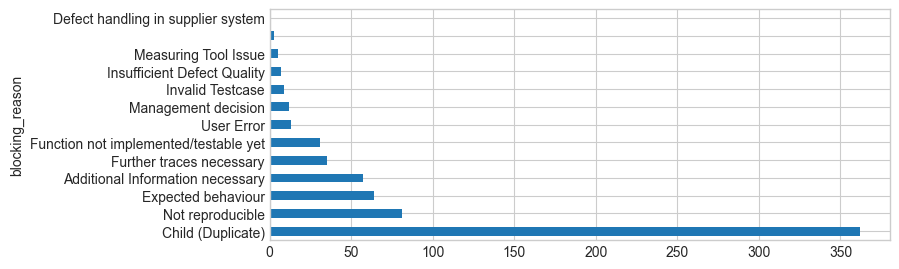

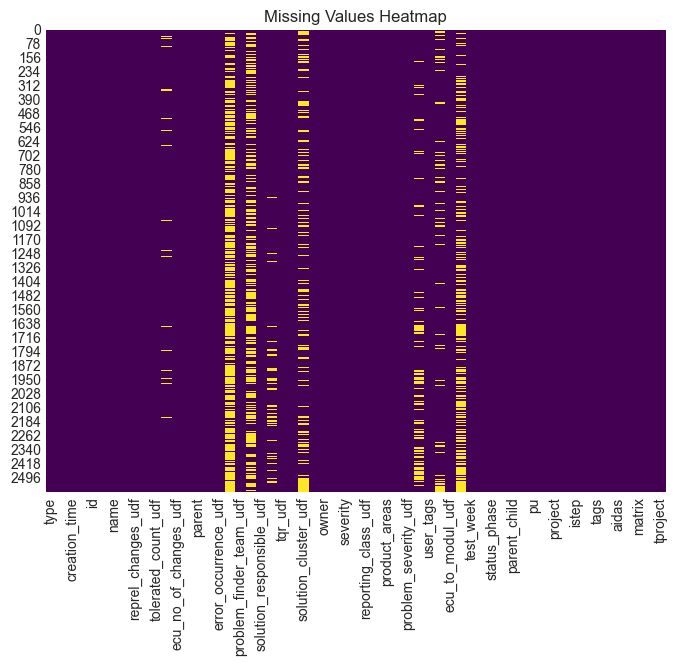

In [17]:
ddf.query("tproject=='IDCEvo' & status_phase=='09-Concluded without action'")["blocking_reason"].value_counts().plot.barh(figsize=(8,3));
plt.figure(figsize=(8, 6))
sns.heatmap(ddf.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

## 数据分析 可视化探索工具

In [16]:
pyg.walk(ddf)

Box(children=(HTML(value='\n<div id="ifr-pyg-000634b083b7c5c5RzQ1meWJPN8sSwFj" style="height: auto">\n    <hea…

In [14]:
import os
import glob

# Network folder path
network_folder_path = r"\\smb-tdaas-1920a.bmwgroup.net\brian-prod\DTSV_China_C"

# List all .txt files in the directory
txt_files = glob.glob(os.path.join(network_folder_path, '*.txt'))

# Function to read a file and parse specific data
def parse_km_state_display_and_vin(text):
    lines = text.split('\n')
    km_state_display = None
    vin = None
    
    for line in lines:
        if line.startswith('KM-State Display:'):
            km_state_display = line.replace('KM-State Display:', '').strip()
        elif line.startswith('VIN (long):'):
            vin = line.replace('VIN (long):', '').strip()
            
    return km_state_display, vin

# Process all files
for file_path in txt_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as file:  # 添加了编码参数
            file_content = file.read()  # 使用read()而不是readline()
            km_state_display, vin = parse_km_state_display_and_vin(file_content)
            
            print(f"File: {os.path.basename(file_path)}")  # 只显示文件名而不是完整路径
            if km_state_display:
                print(f"KM-State Display: {km_state_display}")
            if vin:
                print(f"VIN: {vin}")
            print('---')
    except Exception as e:
        print(f"Error processing file {file_path}: {str(e)}")

## 绘制缺陷状态图表

In [15]:
import plotly.express as px
import pandas as pd
import numpy as np
import re
from ipywidgets import widgets, Layout
from IPython.display import display, clear_output

def extract_english(text):
    if pd.isna(text) or text == '':
        return 'Unknown'
    english_words = re.findall(r'[a-zA-Z]+', str(text))
    return ' '.join(english_words) if english_words else 'Unknown'

# Matrix严重性排序函数
def matrix_severity_order(matrix_value):
    if not matrix_value or not isinstance(matrix_value, str):
        return 999  # 没有Matrix值的放最后
    
    # 提取数字和字母
    match = re.match(r'matrix-(\d)([a-e])', matrix_value.lower())
    if not match:
        return 998  # 格式不符合的放倒数第二
    
    number = int(match.group(1))
    letter = match.group(2)
    
    # 计算排序值 (1A最严重，4D最轻微)
    letter_value = {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4}.get(letter, 5)
    return (number - 1) * 5 + letter_value

# 判断是否为showstopper candidate
def is_showstopper_candidate(matrix_value):
    if not matrix_value or not isinstance(matrix_value, str):
        return False
    
    match = re.match(r'matrix-(\d)([a-e])', matrix_value.lower())
    if not match:
        return False
    
    number = int(match.group(1))
    letter = match.group(2)
    
    # 1A-1E, 2A-2C, 3A为showstopper candidate
    if number == 1:
        return letter.lower() in ['a', 'b', 'c', 'd', 'e']
    elif number == 2:
        return letter.lower() in ['a', 'b', 'c']
    elif number == 3:
        return letter.lower() == 'a'
    return False

def preprocess_defect_data(df):
    df_clean = df.copy()
    
    # 处理缺失值
    for col, val in [('tproject', ''), ('matrix', ''), ('aidas', [])]:
        if col == 'aidas':
            df_clean = df_clean[df_clean[col].apply(lambda x: isinstance(x, list) and len(x) > 0)]
        else:
            df_clean = df_clean[~df_clean[col].isin(['', None, np.nan])]
    
    # 提取AIDA的英文部分
    df_clean['aida_english'] = df_clean['aidas'].apply(
        lambda x: extract_english(x[0]) if isinstance(x, list) and len(x) > 0 else 'Unknown'
    )
    
    # 为Matrix添加排序值
    df_clean['matrix_order'] = df_clean['matrix'].apply(matrix_severity_order)
    
    # 为了更好的可视化，创建一个更友好的Matrix标签
    df_clean['matrix_display'] = df_clean['matrix'].apply(
        lambda x: x if isinstance(x, str) and x.lower().startswith('matrix-') else '未分类')
    
    # 添加严重性分组
    df_clean['severity_group'] = df_clean['matrix'].apply(
        lambda x: 'Showstopper Candidate' if is_showstopper_candidate(x) else '一般问题')
    
    return df_clean

def create_defect_status_dashboard(df_clean, filters=None):
    filtered_data = df_clean.copy()
    
    if filters:
        project, test_week, aida = filters
        filter_conditions = {
            'tproject': project, 
            'test_week': test_week, 
            'aida_english': aida
        }
        for col, val in filter_conditions.items():
            if val != '全部':
                filtered_data = filtered_data[filtered_data[col] == val]
    
    if filtered_data.empty:
        return None, "没有有效的缺陷数据可以显示。"
    
    # 按AIDA和Matrix分组
    defect_status = filtered_data.groupby(['aida_english', 'severity_group', 'matrix_display']).agg(
        缺陷数量=('id', 'count'),
        缺陷ID=('id', list),
        报告人=('tester', lambda x: list(set(x))),
        项目=('tproject', lambda x: list(set(x))),
        原始AIDA=('aidas', lambda x: list(set([str(i[0]) if isinstance(i, list) and len(i) > 0 else 'Unknown' for i in x])))
    ).reset_index()
    
    if defect_status.empty:
        return None, "没有有效的缺陷状态数据。"
    
    # 计算每个AIDA的总数
    aida_totals = defect_status.groupby('aida_english')['缺陷数量'].sum().to_dict()
    
    # 准备绘图数据
    hover_texts = []
    
    for _, row in defect_status.iterrows():
        total = aida_totals[row['aida_english']]
        percentage = round((row['缺陷数量'] / total * 100), 1)
        
        # 准备悬停文本
        ids = row['缺陷ID'][:5]
        reporters = row['报告人'][:3]
        projects = row['项目'][:3]
        
        hover_text = f"<b>{row['原始AIDA'][0]} - {row['matrix_display']}</b><br>"
        hover_text += f"严重性分组: {row['severity_group']}<br>"
        hover_text += f"缺陷数量: {row['缺陷数量']} ({percentage}%)<br>"
        hover_text += f"项目: {', '.join(projects)}<br>"
        hover_text += f"缺陷ID: {', '.join(str(id) for id in ids)}"
        if len(row['缺陷ID']) > 5:
            hover_text += f" 等{len(row['缺陷ID'])}个"
        hover_text += f"<br>报告人: {', '.join(str(t) for t in reporters)}"
        if len(row['报告人']) > 3:
            hover_text += f" 等{len(row['报告人'])}人"
        
        hover_texts.append(hover_text)
    
    defect_status['悬停信息'] = hover_texts
    
    # 按缺陷数量对AIDA进行排序
    aida_order = defect_status.groupby('aida_english')['缺陷数量'].sum().sort_values(ascending=False).index.tolist()
    
    # 合并为按严重性分组的数据
    severity_grouped = defect_status.groupby(['aida_english', 'severity_group']).agg(
        缺陷数量=('缺陷数量', 'sum'),
        悬停信息=('悬停信息', lambda x: '<br>'.join(x))
    ).reset_index()
    
    # 使用Plotly Express创建堆叠条形图
    fig = px.bar(
        severity_grouped,
        x='aida_english',
        y='缺陷数量',
        color='severity_group',
        custom_data=['悬停信息'],
        barmode='stack',
        category_orders={
            'aida_english': aida_order
        },
        color_discrete_map={
            'Showstopper Candidate': '#d62728',  # 红色
            '一般问题': '#2ca02c'                # 绿色
        },
        title="AIDA缺陷分布（按严重性）"
    )
    
    # 设置悬停模板
    fig.update_traces(
        hovertemplate='%{customdata[0]}<extra></extra>'
    )
    
    # 设置标题和布局
    title_text = "所有项目 - 缺陷状态分布" if filters[0] == '全部' else f"项目: {filters[0]} - 缺陷状态分布"
    
    fig.update_layout(
        height=600,
        width=1000,
        title=dict(
            text=f"{title_text}<br><sup>项目: {filters[0]} | 测试周: {filters[1]} | AIDA: {filters[2]}</sup>",
            x=0.5,
            y=0.95,
            font=dict(size=16)
        ),
        template='plotly_white',
        margin=dict(t=120),
        xaxis_title="AIDA领域",
        yaxis_title="缺陷数量",
        xaxis_tickangle=-45,
        legend_title="严重性分组"
    )
    
    # 转换为FigureWidget以支持交互
    fig_widget = widgets.Output()
    with fig_widget:
        display(fig)
    
    return fig_widget, None

def create_defect_dashboard(df):
    df_clean = preprocess_defect_data(df)
    
    required_columns = ['id', 'tproject', 'aidas', 'matrix', 'tester']
    if not all(col in df_clean.columns for col in required_columns):
        print(f"错误：数据中缺少必要的列")
        return
    
    # 获取唯一值用于下拉菜单
    dropdowns = {}
    for col, desc in [('tproject', '项目'), ('test_week', '测试周'), ('aida_english', 'AIDA')]:
        values = sorted([p for p in df_clean[col].unique() if pd.notna(p) and p != ''])
        dropdowns[col] = widgets.Dropdown(
            options=['全部'] + values, value='全部', description=f'{desc}:',
            layout={'width': '180px'}
        )
    
    output = widgets.Output()
    
    def update_charts(change):
        filters = (
            dropdowns['tproject'].value,
            dropdowns['test_week'].value,
            dropdowns['aida_english'].value
        )
        
        with output:
            clear_output(wait=True)  # 清除旧输出
            fig, error_msg = create_defect_status_dashboard(df_clean, filters)
            if fig:
                display(fig)
            else:
                print(error_msg)
    
    # 为所有下拉菜单添加观察者
    for dropdown in dropdowns.values():
        dropdown.observe(update_charts, names='value')
    
    # 创建标题
    title = widgets.HTML("<h2 style='text-align:center; margin-bottom:5px'>缺陷状态看板</h2>")
    
    # 将筛选条件放在一行中
    filter_container = widgets.HBox(list(dropdowns.values()), 
                                   layout=widgets.Layout(justify_content='center', 
                                                        margin='0 0 10px 0'))
    
    # 使用VBox将所有元素垂直排列
    dashboard = widgets.VBox([
        title,
        filter_container,
        output
    ], layout=widgets.Layout(align_items='center'))
    
    display(dashboard)
    update_charts(None)  # 初始显示

# 使用数据框调用函数 
create_defect_dashboard(ddf)

Output()

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import plotly.express as px
import re

# --- Configuration ---
HISTORY_DIR = "./history"
ROADTEST_KEYWORD = "CW15_Roadtest_DTSV"
DEFAULT_DURATION_HOURS = 1 # Default duration for the last phase if end time is missing

# --- Function Definitions ---

def load_history_data(file_path):
    """Loads history data from a JSON file."""
    try:
        with open(file_path, "r", encoding="utf8") as f:
            data = json.load(f)
        if not data or "data" not in data or not data["data"]:
            # print(f"Warning: No valid history events found in {os.path.basename(file_path)}")
            return None, None # Return None if data is invalid or empty
        return data # Return the full raw data
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {os.path.basename(file_path)}")
        return None
    except Exception as e:
        print(f"Error loading file {os.path.basename(file_path)}: {e}")
        return None

def extract_detected_by_name(raw_data):
    """Extracts the full name from the 'detected_by' field in the raw data."""
    # Assumes 'detected_by' is a dictionary at the top level with a 'full_name' key
    if raw_data and isinstance(raw_data.get('detected_by'), dict):
        return raw_data['detected_by'].get('full_name', 'N/A')
    return 'N/A' # Return 'N/A' if not found or structure is wrong

def process_history_events(raw_data, ticket_id, detected_by_name):
    """Normalizes history events, extracts phase, calculates times, and adds metadata."""
    try:
        # Normalize only the 'data' part which contains the history events
        history = pd.json_normalize(raw_data, record_path="data", max_level=0)

        # Add ticket ID and the extracted detected_by name
        history["entity_id"] = ticket_id
        history["detected_by_name"] = detected_by_name # Add the name extracted earlier

        # --- Phase Extraction ---
        if "change_set" not in history.columns:
            # print(f"Warning: 'change_set' column missing for ticket {ticket_id}. Skipping phase processing.")
            return None # Cannot process phases without change_set

        history = history.explode("change_set")
        history["phase"] = history["change_set"].apply(
            lambda x: x.get("value_text") if isinstance(x, dict) and x.get("field_label")=="Phase" else np.nan
        )
        history = history.dropna(subset=["phase"]) # Keep only rows with phase changes

        if history.empty:
            # print(f"Info: No valid phase changes found for ticket {ticket_id} after filtering.")
            return None

        # --- Timestamp Processing and Duration Calculation ---
        if "timestamp" not in history.columns:
            # print(f"Warning: 'timestamp' column missing for ticket {ticket_id}. Cannot calculate timeline.")
            return None

        # Convert timestamp to datetime, coercing errors
        history["start"] = pd.to_datetime(history["timestamp"], errors='coerce', format='ISO8601')
        history = history.dropna(subset=["start"]).sort_values("start") # Remove invalid timestamps and sort

        if history.empty:
            # print(f"Info: No valid timestamps found for ticket {ticket_id} after conversion.")
            return None

        # Calculate end times (start of next phase)
        history["end"] = history["start"].shift(-1)

        # Handle the end time for the very last phase entry for this ticket
        last_idx = history.index[-1]
        if pd.isna(history.loc[last_idx, "end"]):
            history.loc[last_idx, "end"] = history.loc[last_idx, "start"] + pd.Timedelta(hours=DEFAULT_DURATION_HOURS)

        # Calculate duration in days
        history["duration_d"] = (history["end"] - history["start"]).dt.total_seconds() / (24 * 3600)

        # Select and return relevant columns
        return history[['entity_id', 'start', 'end', 'phase', 'detected_by_name', 'duration_d']]

    except Exception as e:
        print(f"Error processing history events for ticket {ticket_id}: {e}")
        return None

def check_contains_keyword(raw_data, keyword):
    """Checks if the raw history data (as string) contains the specified keyword."""
    if not raw_data:
        return False
    # Simple check: convert the whole data structure to string and search
    # This is broad but catches the keyword anywhere (e.g., comments, descriptions, changes)
    try:
        return keyword in json.dumps(raw_data)
    except Exception:
        return False # Handle potential errors during string conversion

def create_timeline_plot(df, title):
    """Creates and returns a Plotly timeline figure."""
    if df.empty:
        print("Cannot create plot: DataFrame is empty.")
        return None

    fig = px.timeline(
        df,
        x_start="start",
        x_end="end",
        color="phase",
        y="entity_id",
        hover_data={
            "detected_by_name": True,       # Show detected_by name
            "duration_d": ':.2f'            # Show duration in days (2 decimal places)
        },
        labels={
            "detected_by_name": "Detected By", # Custom label for hover
            "duration_d": "Duration (Days)"    # Custom label for hover
        }
    )

    fig.update_layout(
        title=title,
        xaxis_title="Time",
        yaxis_title="Ticket ID",
        height=max(600, 50 * df['entity_id'].nunique() + 200) # Dynamic height
    )
    return fig

# --- Main Execution ---

all_processed_history = []
roadtest_tickets_found = set()

# 1. List history files
history_files = [f for f in os.listdir(HISTORY_DIR) if f.endswith("_history.json")]
print(f"Found {len(history_files)} history files in directory '{HISTORY_DIR}'.")

# 2. Process each file
for history_file in history_files:
    file_path = os.path.join(HISTORY_DIR, history_file)
    match = re.search(r'(\d+)_history\.json', history_file)
    if not match:
        # print(f"Warning: Could not extract ticket ID from filename: {history_file}")
        continue
    ticket_id = match.group(1)

    # Load raw data first
    raw_history_data = load_history_data(file_path)
    if raw_history_data is None:
        continue # Skip if loading failed or data invalid

    # Check if this ticket is related to Roadtest *before* detailed processing
    if check_contains_keyword(raw_history_data, ROADTEST_KEYWORD):
        roadtest_tickets_found.add(ticket_id)

    # Extract the 'detected_by' name from the raw data
    detected_by_name = extract_detected_by_name(raw_history_data)

    # Process the history events (normalize, phases, times)
    processed_df = process_history_events(raw_history_data, ticket_id, detected_by_name)

    # Add the processed data (if successful) to our list
    if processed_df is not None:
        all_processed_history.append(processed_df)

# 3. Combine and Filter Data
if not all_processed_history:
    print("No history data was successfully processed.")
else:
    full_history_df = pd.concat(all_processed_history, ignore_index=True)
    print(f"Successfully processed {full_history_df['entity_id'].nunique()} unique tickets.")
    print(f"Found {len(roadtest_tickets_found)} tickets potentially related to '{ROADTEST_KEYWORD}'.")

    # Filter the processed data to include only the roadtest-related tickets
    roadtest_history_df = full_history_df[full_history_df["entity_id"].isin(roadtest_tickets_found)]

    # 4. Create and Show Plot
    if not roadtest_history_df.empty:
        print(f"Generating timeline for {roadtest_history_df['entity_id'].nunique()} roadtest-related tickets...")
        timeline_fig = create_timeline_plot(
            roadtest_history_df,
            f"Phase Timeline for '{ROADTEST_KEYWORD}' Tickets"
        )
        if timeline_fig:
            timeline_fig.show()
    else:
        print(f"No valid phase data found for tickets related to '{ROADTEST_KEYWORD}'. Cannot generate plot.")
